<a href="https://colab.research.google.com/github/ojaspaul123/ML-Experiments/blob/main/Intermmediate/Transforming_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PowerTransformer

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('concrete_file.csv')
df.head()

Saving concrete_file.csv to concrete_file.csv


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
%%markdown
---
Train and test

---
Train and test


In [5]:
from sklearn.model_selection import train_test_split
X= df.drop(['Strength'], axis=1)
y= df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age'],
      dtype='object')

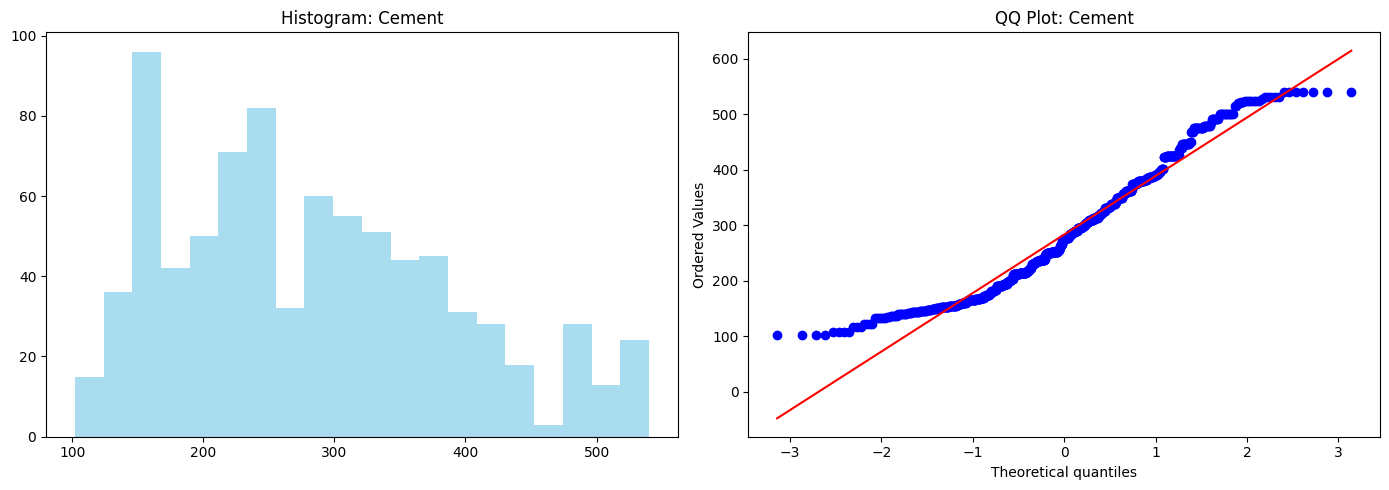

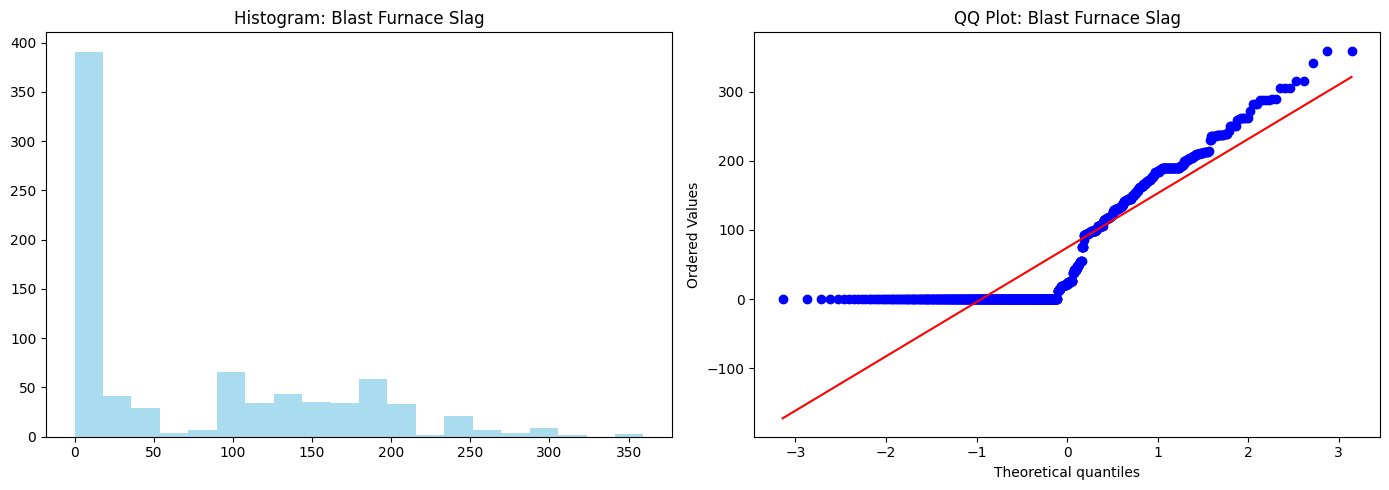

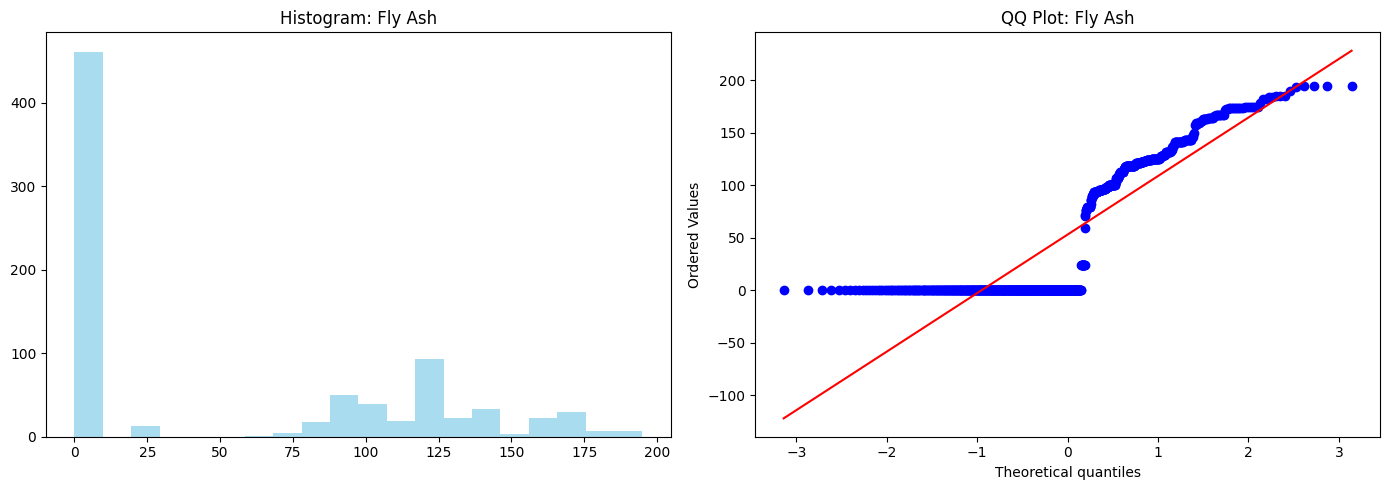

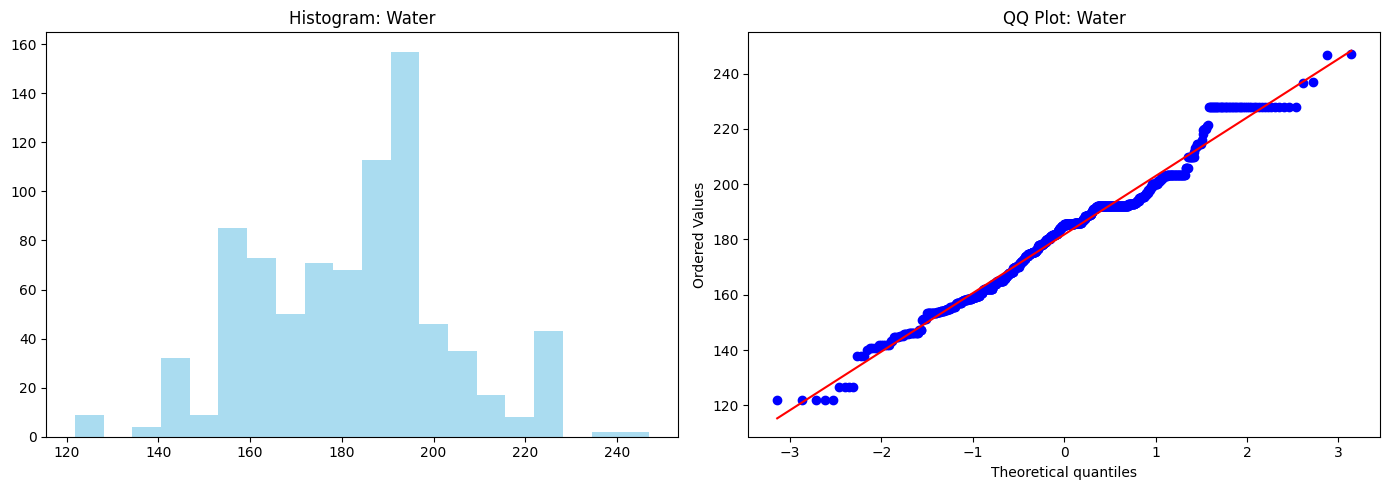

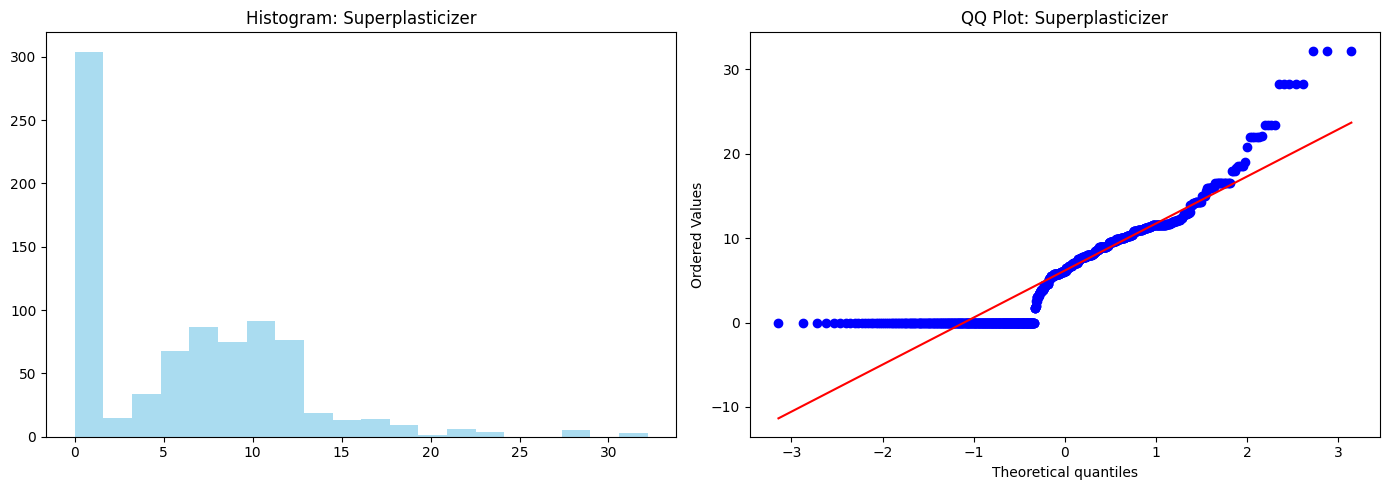

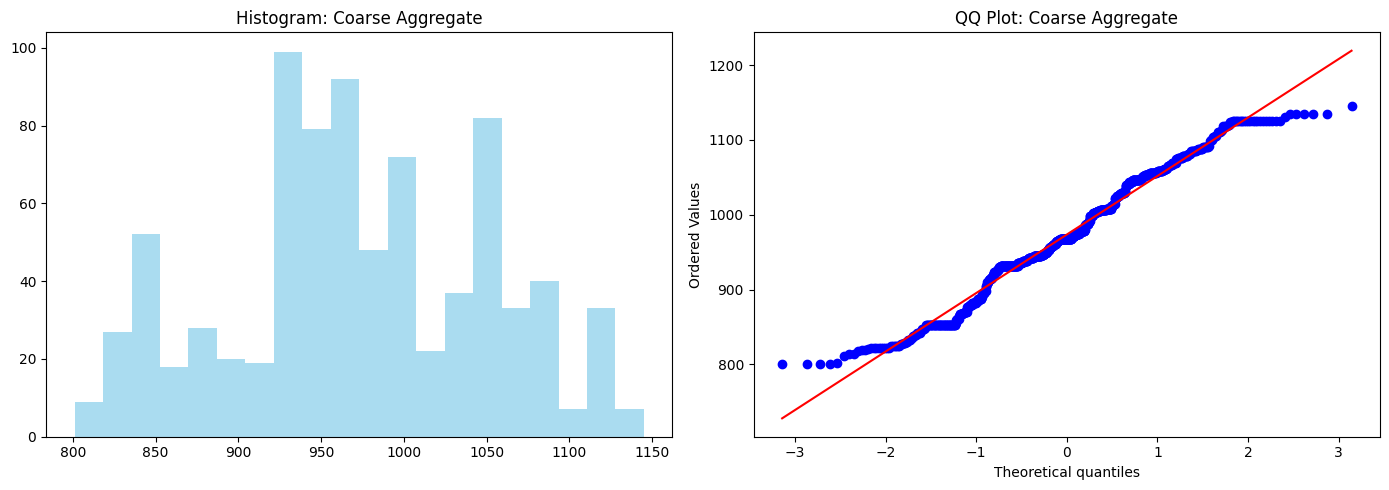

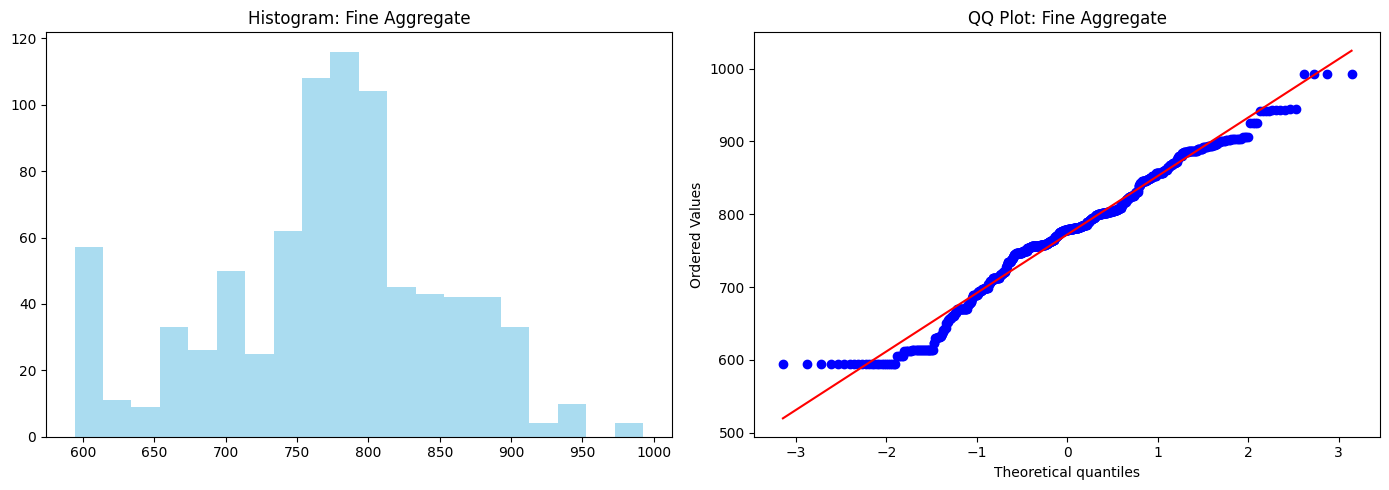

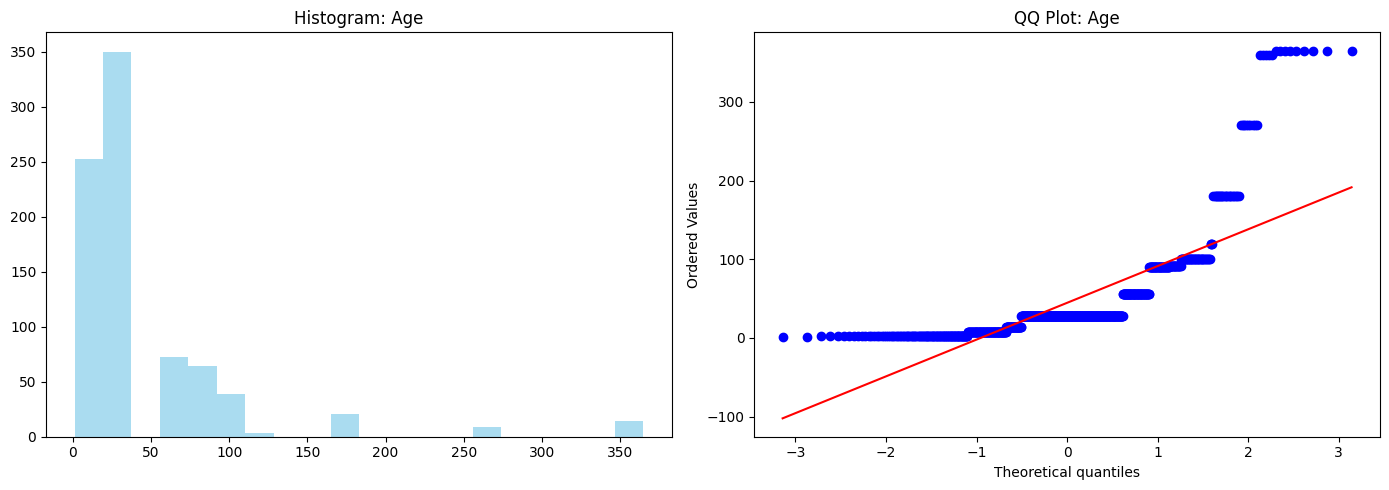

In [9]:
# Plotting the histograms and QQ plots side by side for each column
for col in X_train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(X_train[col], bins=20, color='skyblue', alpha=0.7)
    axes[0].set_title(f'Histogram: {col}')

    # QQ plot
    stats.probplot(X_train[col], dist='norm', plot=axes[1])
    axes[1].set_title(f'QQ Plot: {col}')

    plt.tight_layout()
    plt.show()

In [12]:
# Applying Regression without any transformation
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.627553179231485

In [15]:
%%markdown
---
Applying Box-Cox Transform

---
Applying Box-Cox Transform


In [13]:
pt = PowerTransformer(method='box-cox')
X_train_transformed = pt.fit_transform(X_train+0.00001)
X_test_transformed = pt.transform(X_test+0.00001)

In [14]:
# Applying linear regression on transformed data
lr = LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred = lr.predict(X_test_transformed)
r2_score(y_test,y_pred)

0.8054599368449091

In [17]:
%%markdown
---
Apply Yeo-Johnson transform and linear regression

---
Apply Yeo-Johnson transform and linear regression


In [16]:


pt1 = PowerTransformer()
X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)
y_pred3 = lr.predict(X_test_transformed2)
print(r2_score(y_test,y_pred3))



0.8161906512004999
